Loading original.wav and different.wav...


C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


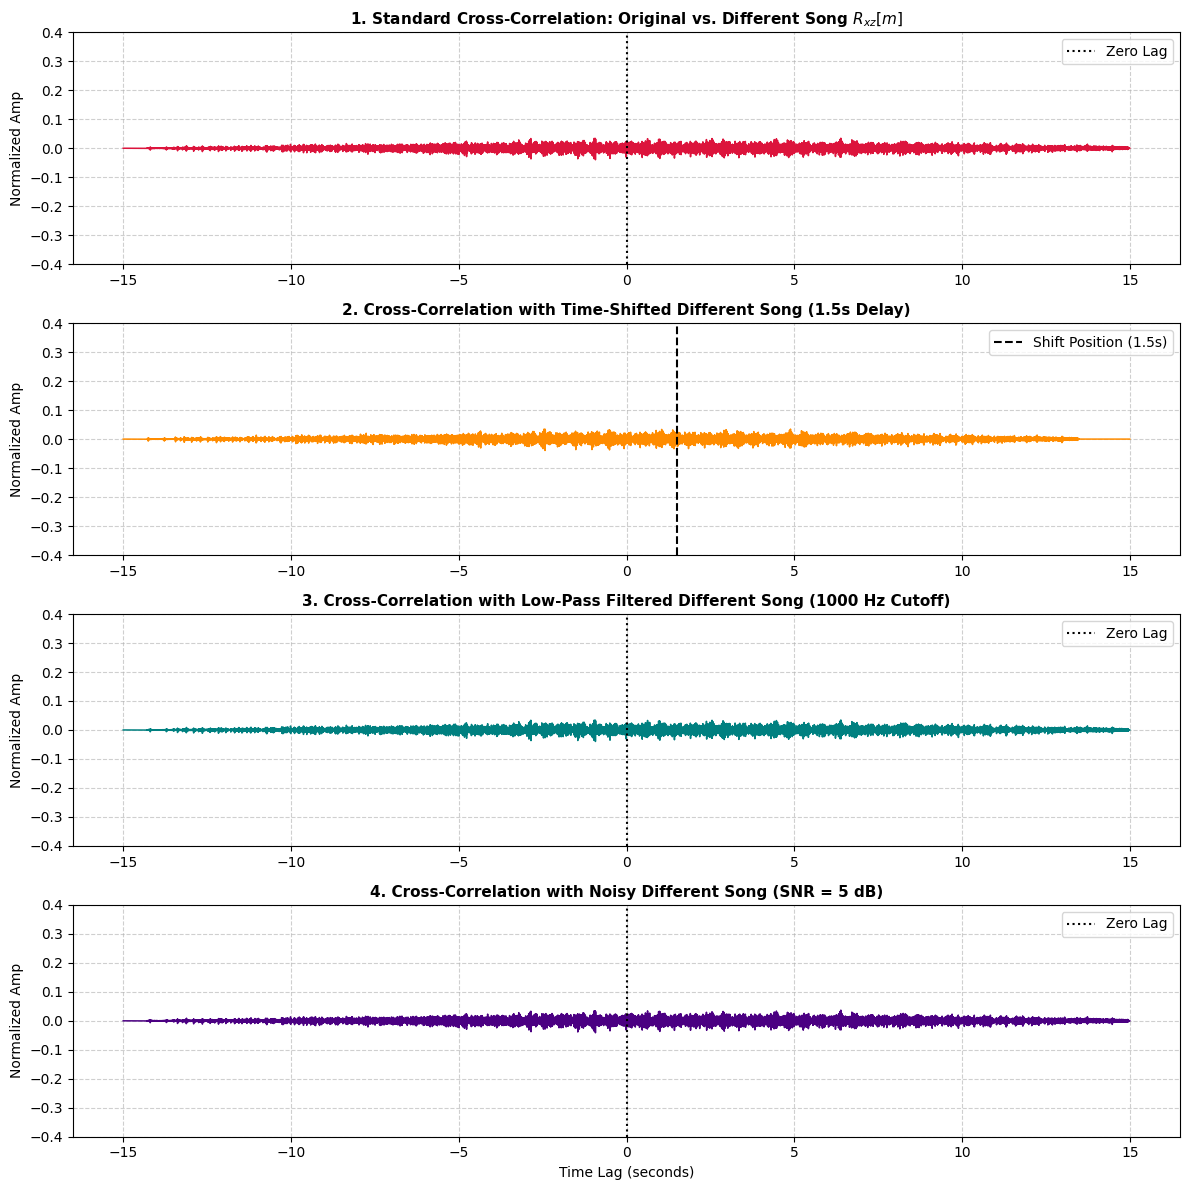

In [1]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

def analyze_comparison_2(file_orig, file_diff, sr=22050, duration=15):
    print(f"Loading {file_orig} and {file_diff}...")
    x, _ = librosa.load(file_orig, sr=sr, mono=True, duration=duration)
    z, _ = librosa.load(file_diff, sr=sr, mono=True, duration=duration)

    min_len = min(len(x), len(z))
    x = x[:min_len]
    z = z[:min_len]

    x = x / np.max(np.abs(x))
    z = z / np.max(np.abs(z))

    delay_sec = 1.5
    delay_samples = int(delay_sec * sr)
    z_delayed = np.pad(z, (delay_samples, 0))[:min_len]

    b, a = signal.butter(4, 1000 / (sr / 2), btype='low')
    z_filtered = signal.filtfilt(b, a, z)

    snr_db = 5
    signal_power = np.mean(z ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), len(z))
    z_noisy = z + noise

    def get_norm_corr(sig1, sig2):
        corr = signal.fftconvolve(sig1, sig2[::-1], mode='full')
   
        return corr / np.max(np.abs(signal.fftconvolve(sig1, sig1[::-1], mode='full')))
    r_xz_base = get_norm_corr(x, z)
    r_xz_delayed = get_norm_corr(x, z_delayed)
    r_xz_filtered = get_norm_corr(x, z_filtered)
    r_xz_noisy = get_norm_corr(x, z_noisy)

    time_lags = np.arange(-min_len + 1, min_len) / sr

    plt.figure(figsize=(12, 12))

    plt.subplot(4, 1, 1)
    plt.plot(time_lags, r_xz_base, color='crimson', linewidth=1.1)
    plt.axvline(0, color='black', linestyle=':', label='Zero Lag')
    plt.title("1. Standard Cross-Correlation: Original vs. Different Song $R_{xz}[m]$", fontsize=11, fontweight='bold')
    plt.ylabel("Normalized Amp")
    plt.ylim(-0.4, 0.4)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.subplot(4, 1, 2)
    plt.plot(time_lags, r_xz_delayed, color='darkorange', linewidth=1.1)
    plt.axvline(delay_sec, color='black', linestyle='--', label=f'Shift Position ({delay_sec}s)')
    plt.title("2. Cross-Correlation with Time-Shifted Different Song (1.5s Delay)", fontsize=11, fontweight='bold')
    plt.ylabel("Normalized Amp")
    plt.ylim(-0.4, 0.4)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.subplot(4, 1, 3)
    plt.plot(time_lags, r_xz_filtered, color='teal', linewidth=1.1)
    plt.axvline(0, color='black', linestyle=':', label='Zero Lag')
    plt.title("3. Cross-Correlation with Low-Pass Filtered Different Song (1000 Hz Cutoff)", fontsize=11, fontweight='bold')
    plt.ylabel("Normalized Amp")
    plt.ylim(-0.4, 0.4)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.subplot(4, 1, 4)
    plt.plot(time_lags, r_xz_noisy, color='indigo', linewidth=1.1)
    plt.axvline(0, color='black', linestyle=':', label='Zero Lag')
    plt.title("4. Cross-Correlation with Noisy Different Song (SNR = 5 dB)", fontsize=11, fontweight='bold')
    plt.xlabel("Time Lag (seconds)")
    plt.ylabel("Normalized Amp")
    plt.ylim(-0.4, 0.4)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analyze_comparison_2("original.wav", "different.wav")

Loading original.wav and different.wav...


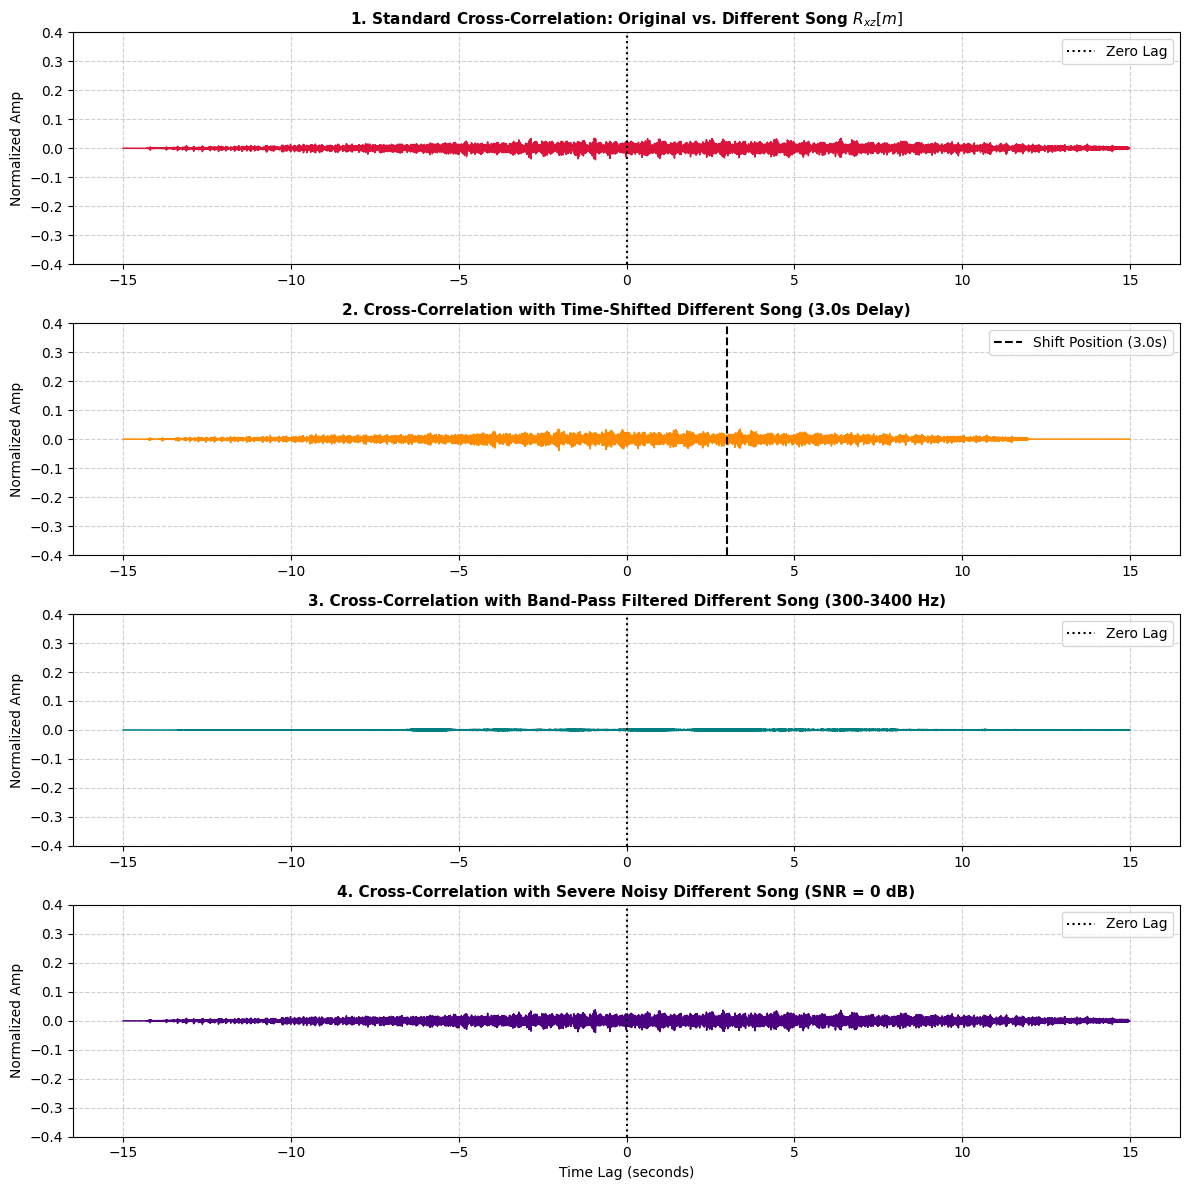

In [ ]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal

def analyze_comparison_2_modified(file_orig, file_diff, sr=22050, duration=15):
    print(f"Loading {file_orig} and {file_diff}...")
    x, _ = librosa.load(file_orig, sr=sr, mono=True, duration=duration)
    z, _ = librosa.load(file_diff, sr=sr, mono=True, duration=duration)

    min_len = min(len(x), len(z))
    x = x[:min_len]
    z = z[:min_len]

    # 2. Peak Normalization
    x = x / np.max(np.abs(x))
    z = z / np.max(np.abs(z))

    
    # Parameter 1: Larger Time Shift (Delay Different track by 3.0 seconds)
    delay_sec = 3.0
    delay_samples = int(delay_sec * sr)
    z_delayed = np.pad(z, (delay_samples, 0))[:min_len]

    # Parameter 2: Band-Pass Filtering (300 Hz - 3400 Hz, Telephone Band)
    lowcut = 300.0
    highcut = 3400.0
    b, a = signal.butter(4, [lowcut / (sr / 2), highcut / (sr / 2)], btype='bandpass')
    z_filtered = signal.filtfilt(b, a, z)

    # Parameter 3: Severe Additive White Gaussian Noise (SNR = 0 dB)
    snr_db = 0  # Signal power equals noise power
    signal_power = np.mean(z ** 2)
    noise_power = signal_power / (10 ** (snr_db / 10))
    noise = np.random.normal(0, np.sqrt(noise_power), len(z))
    z_noisy = z + noise

    def get_norm_corr(sig1, sig2):
        corr = signal.fftconvolve(sig1, sig2[::-1], mode='full')
        return corr / np.max(np.abs(signal.fftconvolve(sig1, sig1[::-1], mode='full')))

    # Cross-correlations
    r_xz_base = get_norm_corr(x, z)
    r_xz_delayed = get_norm_corr(x, z_delayed)
    r_xz_filtered = get_norm_corr(x, z_filtered)
    r_xz_noisy = get_norm_corr(x, z_noisy)

    # Time lag axis in seconds
    time_lags = np.arange(-min_len + 1, min_len) / sr

    plt.figure(figsize=(12, 12))

    # Plot 1: Standard Cross-Correlation (Original vs Different)
    plt.subplot(4, 1, 1)
    plt.plot(time_lags, r_xz_base, color='crimson', linewidth=1.1)
    plt.axvline(0, color='black', linestyle=':', label='Zero Lag')
    plt.title("1. Standard Cross-Correlation: Original vs. Different Song $R_{xz}[m]$", fontsize=11, fontweight='bold')
    plt.ylabel("Normalized Amp")
    plt.ylim(-0.4, 0.4)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Plot 2: Modified Time Shift (3.0s Delay)
    plt.subplot(4, 1, 2)
    plt.plot(time_lags, r_xz_delayed, color='darkorange', linewidth=1.1)
    plt.axvline(delay_sec, color='black', linestyle='--', label=f'Shift Position ({delay_sec}s)')
    plt.title(f"2. Cross-Correlation with Time-Shifted Different Song ({delay_sec}s Delay)", fontsize=11, fontweight='bold')
    plt.ylabel("Normalized Amp")
    plt.ylim(-0.4, 0.4)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Plot 3: Band-Pass Filtered Cross-Correlation
    plt.subplot(4, 1, 3)
    plt.plot(time_lags, r_xz_filtered, color='teal', linewidth=1.1)
    plt.axvline(0, color='black', linestyle=':', label='Zero Lag')
    plt.title("3. Cross-Correlation with Band-Pass Filtered Different Song (300-3400 Hz)", fontsize=11, fontweight='bold')
    plt.ylabel("Normalized Amp")
    plt.ylim(-0.4, 0.4)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # Plot 4: Severe Noise Cross-Correlation (SNR = 0 dB)
    plt.subplot(4, 1, 4)
    plt.plot(time_lags, r_xz_noisy, color='indigo', linewidth=1.1)
    plt.axvline(0, color='black', linestyle=':', label='Zero Lag')
    plt.title("4. Cross-Correlation with Severe Noisy Different Song (SNR = 0 dB)", fontsize=11, fontweight='bold')
    plt.xlabel("Time Lag (seconds)")
    plt.ylabel("Normalized Amp")
    plt.ylim(-0.4, 0.4)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analyze_comparison_2_modified("original.wav", "different.wav")